In [23]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


Import the libraries required for coding.

In [24]:

# Library for interacting with the operating system
# Used to access file paths, get current working directory, and manage files/folders
import os
# Core library for structured data manipulation and analysis
# Essential for loading, cleaning, exploring and transforming tabular data 
import pandas as pd

# Print current working directory to verify file path location
print(os.getcwd())

# Library for retrieving system-related information
# Used to identify operating system type, Python version, and hardware details
import platform

# Fundamental plotting library for creating static, interactive visualizations
# Used to generate basic charts (histograms, bar plots, scatter plots, etc.) for data exploration
import matplotlib.pyplot as plt  

# Advanced statistical visualization library built on Matplotlib
# Provides aesthetically pleasing plots for statistical analysis
import seaborn as sns    

# Module for statistical functions and hypothesis testing
# Used for statistical tests (t-tests, chi-square tests), probability distributions and statistical inference
from scipy import stats  

# Function to split data into training and testing sets
# Essential for evaluating machine learning model performance on unseen data
from sklearn.model_selection import train_test_split

# Implementation of logistic regression algorithm
# Used for binary/multiclass classification tasks in business data analysis
from sklearn.linear_model import LogisticRegression

# sklearn.metrics.accuracy_score: Metric to calculate classification accuracy
# Used to evaluate how well the logistic regression model predicts outcomes
from sklearn.metrics import accuracy_score

/Applications/python


Read data using the pandas library, remove garbled characters, and check if the file can be downloaded normally.


In [25]:
import os
import pandas as pd
print(os.getcwd())
import platform
df=pd.read_csv(r"marketing_campaign.csv")


def load_and_preprocess_data(file_path):   
    try:    
        # Read CSV file 
        df = pd.read_csv(
            file_path,
            encoding='utf-8', 
            low_memory=False      
        )        
        print("\n===Dataset loaded successfully!===")   
    # Catch FileNotFoundError   
    except FileNotFoundError:    
        
        desktop_path = r"~"  
        dataset_name = os.path.basename(file_path)
        
        print(f"\n Error: '{dataset_name}' not found on desktop!")    
        for file in os.listdir(desktop_path):        
            print(f"   - {file}")
        exit()  # Terminate the program to avoid errors in subsequent code





        D

/Applications/python


First, check the number of rows and columns of the dataset to verify if it meets the requirements.Then, view the first five rows of the data and the corresponding data types. Finally, count the number of numerical columes and categorical columes

In [26]:
print("\n===Basic Dataset Validation===")

#Check dataset row count (assignment requirement: 1000-5000 rows)
row_count = len(df)
col_count = len(df.columns)
print(f"Total rows: {row_count}")
print(f"Total columns: {col_count}")
# Verify if row count meets the requirements
if 1000 <= row_count <= 5000:    
    print("Row count meets assignment requirements (1000-5000 rows)")    
else:    
    print(f"Warning: Row count ({row_count}) does not meet requirements (1000-5000 rows)")    
    
# View first 5 rows of data 
print("\n=== First 5 Rows ===")
print(df.head())

# View data types 
print("\n=== Data Types ===")
print(df.dtypes)

# Count number of numeric/categorical columns 
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")


===Basic Dataset Validation===
Total rows: 2240
Total columns: 29
Row count meets assignment requirements (1000-5000 rows)

=== First 5 Rows ===
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  04-09-2012       58       635  ...                  7             0   
1  08-03-2014       38        11  ...                  5             0   
2  21-08-2013       26       426  ...                  4             0   
3  10-02-2014       26        11  ...                  6             0   
4  19-01-2014  

Find missing values, fill numeric columns with the mean, drop duplicates, and standardize date formats.

In [27]:
print("\n===Targeted Preprocessing===")

# Missing value handling 
print("\n1. Missing Value Handling")
missing_count = df.isnull().sum()
missing_cols = missing_count[missing_count > 0].index.tolist()

if missing_cols:
    print(f"Columns with missing values: {missing_cols}")
    # Fill numeric columns with mean 
    for col in missing_cols:
        if col in numeric_cols:
            fill_value = df[col].mean()
            df["Dt_Customer"] = df["Dt_Customer"].fillna(fill_value)
            print(f"Filled '{col}' with mean: {fill_value:.2f}")
else:
    print("No missing values in dataset")

# Duplicate value handling 
print("\n2. Duplicate Handling")
duplicate_count = df.duplicated().sum()
if duplicate_count > 0:
    df.drop_duplicates(inplace=True)
    print(f"Removed {duplicate_count} duplicate rows")
else:
    print("No duplicate rows")

# Data format optimization 
print("\n3. Date Format Optimization")
if "Dt_Customer" in df.columns:
    df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format='%d-%m-%Y')
    print("Converted 'Dt_Customer' to datetime format")
    print("Sample of 'Dt_Customer':")
    print(df["Dt_Customer"].head())


===Targeted Preprocessing===

1. Missing Value Handling
Columns with missing values: ['Income']
Filled 'Income' with mean: 52247.25

2. Duplicate Handling
No duplicate rows

3. Date Format Optimization
Converted 'Dt_Customer' to datetime format
Sample of 'Dt_Customer':
0   2012-09-04
1   2014-03-08
2   2013-08-21
3   2014-02-10
4   2014-01-19
Name: Dt_Customer, dtype: datetime64[ns]


Output the row and column data after data cleaning.


In [28]:
print("\n===Preprocessing Result Validation===")

final_missing = df.isnull().sum().sum()
print(f"Total missing values after preprocessing: {final_missing}")

# Verify final dataset size
final_row_count = len(df)
print(f"Final dataset size: {final_row_count} rows * {col_count} columns")


===Preprocessing Result Validation===
Total missing values after preprocessing: 24
Final dataset size: 2240 rows * 29 columns


Combine several spendings and calculate the total spending.

In [29]:
# Remove missing values
df = df.dropna()

# Create Total Spending (IMPORTANT)
df['Total_Spending'] = (
    df['MntWines'] +
    df['MntFruits'] +
    df['MntMeatProducts'] +
    df['MntFishProducts'] +
    df['MntSweetProducts'] +
    df['MntGoldProds']
)
print("After Cleaning:")
print(df.info())

After Cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 2216 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2216 non-null   int64         
 1   Year_Birth           2216 non-null   int64         
 2   Education            2216 non-null   object        
 3   Marital_Status       2216 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2216 non-null   int64         
 6   Teenhome             2216 non-null   int64         
 7   Dt_Customer          2216 non-null   datetime64[ns]
 8   Recency              2216 non-null   int64         
 9   MntWines             2216 non-null   int64         
 10  MntFruits            2216 non-null   int64         
 11  MntMeatProducts      2216 non-null   int64         
 12  MntFishProducts      2216 non-null   int64         
 13  MntSweetProducts     2

In [30]:
print("\nSummary Statistics:")
print(df[['Income', 'Total_Spending']].describe())


Summary Statistics:
              Income  Total_Spending
count    2216.000000     2216.000000
mean    52247.251354      607.075361
std     25173.076661      602.900476
min      1730.000000        5.000000
25%     35303.000000       69.000000
50%     51381.500000      396.500000
75%     68522.000000     1048.000000
max    666666.000000     2525.000000


In [31]:
pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.


Determine the most frequent spending stage.


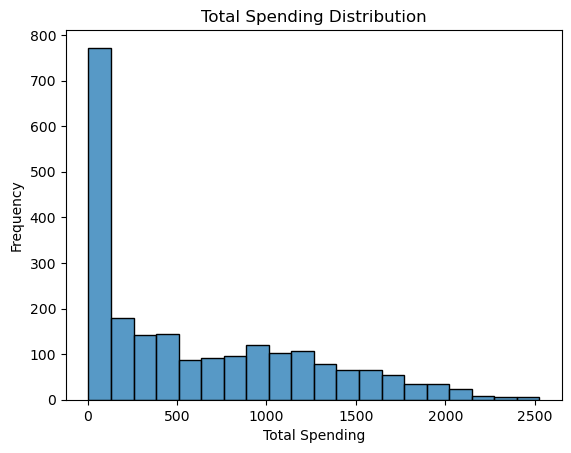

In [32]:
import matplotlib.pyplot as plt  
import seaborn as sns           

# (1) Distribution of Total Spending
plt.figure()
sns.histplot(df['Total_Spending'], bins=20)
plt.title("Total Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Frequency")
plt.show()

Examine the relationship between education level and total spending.

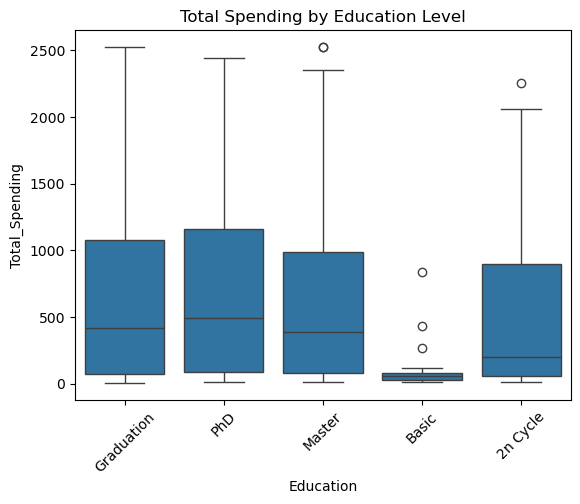

In [33]:
# (2) Spending by Education
plt.figure()
sns.boxplot(x='Education', y='Total_Spending', data=df)
plt.xticks(rotation=45)
plt.title("Total Spending by Education Level")
plt.show()

Examine the relationship between Income and total spending.

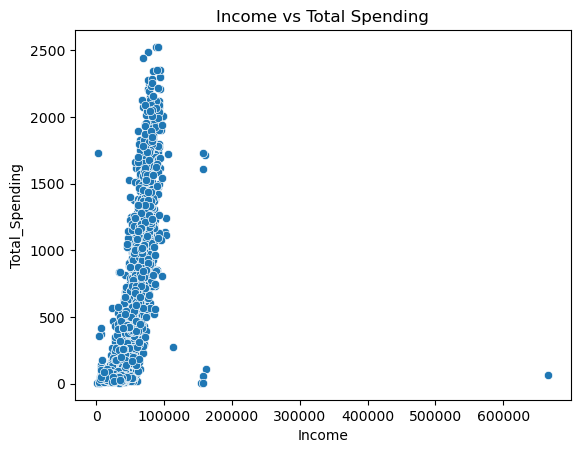

In [34]:
# (3) Income vs Spending (VERY IMPORTANT)
plt.figure()
sns.scatterplot(x='Income', y='Total_Spending', data=df)
plt.title("Income vs Total Spending")
plt.show()

Classify groups based on total spending.


In [35]:
def classify_spending(x):
    if x > 1000:
        return "High"
    elif x > 500:
        return "Medium"
    else:
        return "Low"
df['Spending_Level'] = df['Total_Spending'].apply(classify_spending)  

Calculate the total amount for each stage.

In [36]:
print("\nSpending Level Count:")
print(df['Spending_Level'].value_counts())
total_spending = 0
for x in df['Total_Spending']:
    total_spending += x
print("\nTotal Spending:", total_spending) 


Spending Level Count:
Spending_Level
Low       1231
High       598
Medium     387
Name: count, dtype: int64

Total Spending: 1345279


In [37]:
def average_spending(data):
    return sum(data) / len(data)

avg = average_spending(df['Total_Spending'])
print("\nAverage Spending:", avg)


Average Spending: 607.0753610108303


In [38]:
# Average spending by education
edu_spending = df.groupby('Education')['Total_Spending'].mean()
print("\nAverage Spending by Education:")
print(edu_spending)



Average Spending by Education:
Education
2n Cycle      494.930000
Basic          81.796296
Graduation    621.686380
Master        609.767123
PhD           676.733888
Name: Total_Spending, dtype: float64


generates a bar chart to visualize and compare the average spending across different education levels.

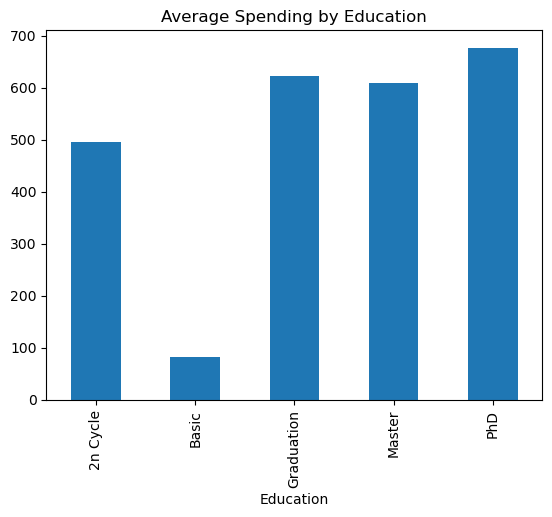

In [39]:
# Plot
plt.figure()
edu_spending.plot(kind='bar')
plt.title("Average Spending by Education")
plt.show()

In [40]:
# Correlation
corr = df[['Income', 'Total_Spending']].corr()
print("\nCorrelation between Income and Spending:")
print(corr)


Correlation between Income and Spending:
                  Income  Total_Spending
Income          1.000000        0.667576
Total_Spending  0.667576        1.000000


In [41]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Total_Spending,Spending_Level
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,...,0,0,0,0,0,3,11,1,1617,High
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,...,0,0,0,0,0,3,11,0,27,Low
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,...,0,0,0,0,0,3,11,0,776,Medium
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,...,0,0,0,0,0,3,11,0,53,Low
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,...,0,0,0,0,0,3,11,0,422,Low


This step conducts an independent two-sample t-test to statistically verify whether there is a significant difference in average income between customers who accepted the marketing offer and those who did not.


In [42]:
from scipy import stats  

accepted = df[df['Response'] == 1]['Income']
not_accepted = df[df['Response'] == 0]['Income']

# t-test
t_stat, p_value = stats.ttest_ind(accepted, not_accepted, nan_policy='omit')

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 6.316420548976486
p-value: 3.2255685843409974e-10


This step builds a logistic regression model using customer behavioral and demographic features to predict marketing response, then evaluates the model’s predictive performance with test set accuracy.


In [43]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# define the variable
X = df[['Income', 'Recency', 'MntWines', 'MntMeatProducts']]
y = df['Response']

# set train and test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# train model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.831081081081081
